# Synthetic Fantasy Draft MDP walkthrough

This notebook exercises the environment end to end without implementing an RL algorithm. It demonstrates:

- heterogeneous league and roster configuration
- synthetic player generation
- physical-only draft legality and snake order
- controlled and opponent policy picks
- fixed-dimensional state encoding
- completed rosters, free agents, and season simulation
- injury information known before an ex-ante lineup decision
- nested Monte Carlo state evaluation
- heterogeneous state generation and metadata

All examples use fixed seeds so rerunning the notebook reproduces the same results.

In [36]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# Purge any cached in-memory modules if re-running in an existing Jupyter kernel
for mod in list(sys.modules):
    if mod.startswith("fantasy_draft"):
        del sys.modules[mod]

import numpy as np

# Make the src-layout package importable whether the kernel starts in the
# repository root or in notebooks/.
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from fantasy_draft.config import LeagueConfig, RosterConfig
from fantasy_draft.draft import DraftEnvironment
from fantasy_draft.evaluation import EvaluationSeedPlan, evaluate_state
from fantasy_draft.generation import generate_states
from fantasy_draft.models import POSITIONS, Position
from fantasy_draft.players import generate_players
from fantasy_draft.policies import RosterAwareSoftmaxPolicy
from fantasy_draft.season import SeasonSimulator, mean_weekly_score
from fantasy_draft.state import ENCODER_VERSION, StateEncoder, remaining_requirements

SEED = 42
rng = np.random.default_rng(SEED)
print(f"Repository: {ROOT}")
print(f"Encoder version: {ENCODER_VERSION}")

Repository: /Users/zubinoommen/Documents/senior year/fall/projects/fantasy drafter rl
Encoder version: 2


## 1. Configure a league and generate players

This example uses ten teams and two FLEX slots. Draft length is derived from the eleven-player roster. The same classes also support 8/12 teams, 2-QB lineups, custom FLEX eligibility, benches, and explicit physical position limits.

In [37]:
roster_config = RosterConfig(
    required={
        Position.QB: 1,
        Position.RB: 2,
        Position.WR: 2,
        Position.TE: 1,
    },
    flex_slots=2,
    flex_eligible=(Position.RB, Position.WR, Position.TE),
    bench_slots=3,
)
league = LeagueConfig(
    n_teams=10,
    controlled_team=3,  # zero-based: fourth draft position
    roster=roster_config,
)
players = generate_players(seed=SEED)

print("Teams:", league.n_teams)
print("Roster size / rounds:", roster_config.roster_size, league.n_rounds)
print("Total draft picks:", league.total_picks)
print("Controlled draft position:", league.controlled_team + 1)
print("Player pool size:", len(players))

for position in POSITIONS:
    group = [player for player in players if player.position == position]
    print(
        position.value,
        "count=", len(group),
        "mean(mu)=", round(float(np.mean([p.mu for p in group])), 2),
        "best(mu)=", max(p.mu for p in group),
    )

Teams: 10
Roster size / rounds: 11 11
Total draft picks: 110
Controlled draft position: 4
Player pool size: 120
QB count= 24 mean(mu)= 17.63 best(mu)= 24.3347
RB count= 36 mean(mu)= 10.07 best(mu)= 21.7545
WR count= 42 mean(mu)= 11.9 best(mu)= 21.4463
TE count= 18 mean(mu)= 7.83 best(mu)= 16.4197


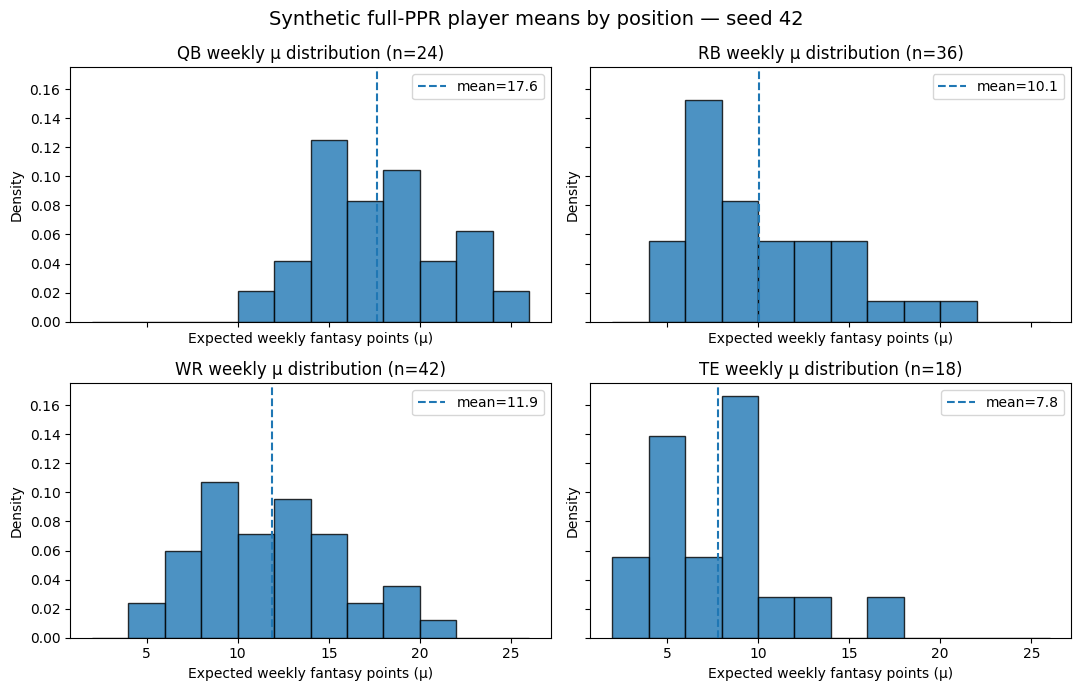

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
bins = np.arange(2, 28, 2)
for axis, position in zip(axes.flat, POSITIONS, strict=True):
    values = [player.mu for player in players if player.position == position]
    axis.hist(values, bins=bins, density=True, alpha=0.8, edgecolor="black")
    axis.axvline(np.mean(values), linestyle="--", linewidth=1.5, label=f"mean={np.mean(values):.1f}")
    axis.set_title(f"{position.value} weekly μ distribution (n={len(values)})")
    axis.set_xlabel("Expected weekly fantasy points (μ)")
    axis.set_ylabel("Density")
    axis.legend()
fig.suptitle("Synthetic full-PPR player means by position — seed 42", fontsize=14)
fig.tight_layout()
plt.show()

## 2. Inspect the draft environment

`DraftEnvironment.step` is deterministic once a player ID is chosen. Legality enforces only physical rules: the player must be available, the roster must have space, and any explicitly configured physical position limit must be respected. It does not enforce good strategy or a complete starting lineup.

In [39]:
environment = DraftEnvironment(league)
initial_state = environment.initial_state(players)
state = initial_state

first_two_rounds = [environment.team_at_pick(i) + 1 for i in range(2 * league.n_teams)]
print("Snake order, first two rounds:", first_two_rounds)
print("Current team:", state.current_team + 1)
print("Current round:", state.round_number)
print("Available players:", len(state.available_ids))
print("Legal actions:", len(environment.legal_actions(state)))
print(
    "Picks until controlled team:",
    environment.picks_until_team(state, league.controlled_team),
)

# A round-one QB—and even repeated QBs later—remain physically legal.
lookup = state.player_map
legal_qbs = [pid for pid in environment.legal_actions(state) if lookup[pid].position == Position.QB]
print("Round-one QBs currently legal:", len(legal_qbs))

Snake order, first two rounds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
Current team: 1
Current round: 1
Available players: 120
Legal actions: 120
Picks until controlled team: 3
Round-one QBs currently legal: 24


## 3. Roll out visible picks

Every team—including the controlled team—uses the same stochastic, configuration-aware policy in this demonstration. It blends raw `mu`, marginal value above a league-derived replacement level, and soft starter/FLEX need bonuses. Strategically awkward picks remain legal.

In [40]:
shared_policy = RosterAwareSoftmaxPolicy(
    temperature=3.0,
    starter_need_bonus=6.0,
    flex_need_bonus=2.5,
    value_above_replacement_weight=1.0,
)
draft_rng = np.random.default_rng(2026)
pick_log = []

for _ in range(16):
    drafting_team = state.current_team
    player_id = shared_policy.select_player(state, environment, draft_rng)
    selected = state.player_map[player_id]
    pick_log.append(
        (
            state.pick_index + 1,
            state.round_number,
            drafting_team + 1,
            selected.player_id,
            selected.position.value,
            selected.mu,
            shared_policy.name,
        )
    )
    state = environment.step(state, player_id, validate=False)

print("pick  rnd  team  player  pos    mu   shared policy")
for row in pick_log:
    print(f"{row[0]:>4}  {row[1]:>3}  {row[2]:>4}  {row[3]:>6}  {row[4]:>3}  {row[5]:>5.1f}  {row[6]}")

partial_state = state
print("\nControlled roster after these picks:")
for player in partial_state.roster_players(league.controlled_team):
    print(player.position.value, player.player_id, player.mu)

pick  rnd  team  player  pos    mu   shared policy
   1    1     1      24   RB   21.8  roster_softmax_t3_s6_f2.5_vor1
   2    1     2      61   WR   19.8  roster_softmax_t3_s6_f2.5_vor1
   3    1     3      60   WR   21.4  roster_softmax_t3_s6_f2.5_vor1
   4    1     4      25   RB   18.3  roster_softmax_t3_s6_f2.5_vor1
   5    1     5       5   QB   20.6  roster_softmax_t3_s6_f2.5_vor1
   6    1     6      69   WR   15.3  roster_softmax_t3_s6_f2.5_vor1
   7    1     7     102   TE   16.4  roster_softmax_t3_s6_f2.5_vor1
   8    1     8       0   QB   24.3  roster_softmax_t3_s6_f2.5_vor1
   9    1     9      62   WR   19.7  roster_softmax_t3_s6_f2.5_vor1
  10    1    10       3   QB   22.0  roster_softmax_t3_s6_f2.5_vor1
  11    2    10     103   TE   13.4  roster_softmax_t3_s6_f2.5_vor1
  12    2     9      68   WR   15.4  roster_softmax_t3_s6_f2.5_vor1
  13    2     8      63   WR   18.3  roster_softmax_t3_s6_f2.5_vor1
  14    2     7      52   RB    6.9  roster_softmax_t3_s6_f2.5_vo

## 4. Encode the partial state

The model-facing vector has the same dimensionality across supported league configurations. It explicitly includes league size, lineup rules, FLEX eligibility, scoring context, draft progress, a masked player board, a padded/masked roster, and remaining requirements.

In [41]:
encoder = StateEncoder()
vector = encoder.encode_state(partial_state)
names = encoder.feature_names(partial_state)
slices = encoder.slices(partial_state)

print("Vector shape:", vector.shape)
print("Slices:", {name: (part.start, part.stop) for name, part in slices.items()})
for feature in [
    "config.num_teams",
    "config.controlled_team_index",
    "config.roster_size",
    "config.starters.QB",
    "config.flex_slots",
    "draft.current_round",
    "draft.normalized_progress",
    "draft.picks_until_controlled",
    "draft.rounds_remaining",
]:
    print(f"{feature:35s} = {vector[names.index(feature)]:.3f}")

print("Remaining QB/RB/WR/TE/FLEX/reserve:", remaining_requirements(partial_state))

Vector shape: (390,)
Slices: {'context': (0, 64), 'board': (64, 224), 'roster': (224, 384), 'requirements': (384, 390)}
config.num_teams                    = 10.000
config.controlled_team_index        = 3.000
config.roster_size                  = 11.000
config.starters.QB                  = 1.000
config.flex_slots                   = 2.000
draft.current_round                 = 2.000
draft.normalized_progress           = 0.145
draft.picks_until_controlled        = 0.000
draft.rounds_remaining              = 10.000
Remaining QB/RB/WR/TE/FLEX/reserve: [1. 1. 2. 1. 2. 3.]


## 5. Complete the draft

We continue using the same shared policy for every team. Completion means every team made its configured number of physical picks—not that every roster is strategically sound.

In [42]:
terminal_state = partial_state
controlled_future_picks = []
while not terminal_state.is_terminal:
    drafting_team = terminal_state.current_team
    player_id = shared_policy.select_player(terminal_state, environment, draft_rng)
    if drafting_team == league.controlled_team:
        player = terminal_state.player_map[player_id]
        controlled_future_picks.append((terminal_state.round_number, player.position.value, player.mu))
    terminal_state = environment.step(terminal_state, player_id, validate=False)

controlled_roster = terminal_state.roster_players(league.controlled_team)
free_agents = terminal_state.available_players()
print("Draft terminal:", terminal_state.is_terminal)
print("Total picks:", terminal_state.pick_index)
print("Controlled continuation picks:", controlled_future_picks)
print("Controlled roster size:", len(controlled_roster))
print("Undrafted free agents:", len(free_agents))
print("\nFinal controlled roster:")
for position in POSITIONS:
    group = sorted(
        (player for player in controlled_roster if player.position == position),
        key=lambda player: -player.mu,
    )
    print(position.value, [(player.player_id, player.mu) for player in group])
print("Remaining lineup requirements:", remaining_requirements(terminal_state))

Draft terminal: True
Total picks: 110
Controlled continuation picks: [(2, 'QB', 18.755), (3, 'QB', 20.5947), (4, 'WR', 14.1167), (5, 'WR', 12.5317), (6, 'WR', 12.6152), (7, 'QB', 16.4246), (8, 'RB', 9.9743), (9, 'QB', 14.7463), (10, 'RB', 6.8939), (11, 'RB', 6.7893)]
Controlled roster size: 11
Undrafted free agents: 10

Final controlled roster:
QB [(4, 20.5947), (9, 18.755), (14, 16.4246), (18, 14.7463)]
RB [(25, 18.2932), (39, 9.9743), (51, 6.8939), (53, 6.7893)]
WR [(71, 14.1167), (75, 12.6152), (77, 12.5317)]
TE []
Remaining lineup requirements: [0. 0. 0. 1. 0. 0.]


## 6. Simulate a season

For each week, injury availability is revealed before lineup lock. The waiver model then fills structural holes where possible, and the lineup is selected **ex ante using `mu`**. Only after those IDs are locked are realized scores applied. There are no surprise in-game injuries and no use of realized scoring to choose starters.

In [43]:
simulator = SeasonSimulator(roster_config=league.roster, n_weeks=4)
season = simulator.simulate(
    roster=controlled_roster,
    free_agents=free_agents,
    seed=314,
    player_universe=terminal_state.players,
)
all_players = terminal_state.player_map

for week, lineup in enumerate(season.lineups, start=1):
    selected = [
        f"{all_players[player_id].position.value}{player_id}"
        for player_id in lineup.selected_ids
    ]
    print(
        f"week {week}: score={lineup.score:6.2f}",
        f"lineup={selected}",
        f"waiver_ids={list(lineup.replacement_ids)}",
    )
print("Mean weekly utility:", round(mean_weekly_score(season.weekly_scores), 3))

week 1: score=124.64 lineup=['QB4', 'RB51', 'RB53', 'WR71', 'WR75', 'TE118', 'WR77', 'WR101'] waiver_ids=[118, 101]
week 2: score=103.00 lineup=['QB4', 'RB39', 'RB51', 'WR71', 'WR75', 'TE119', 'WR77', 'RB53'] waiver_ids=[119]
week 3: score= 71.08 lineup=['QB4', 'RB25', 'RB39', 'WR75', 'WR98', 'TE118', 'RB51', 'RB53'] waiver_ids=[98, 118]
week 4: score=112.71 lineup=['QB4', 'RB25', 'RB39', 'WR71', 'WR75', 'TE118', 'WR77', 'RB51'] waiver_ids=[118]
Mean weekly utility: 102.857


## 7. Estimate a partial state's value

`evaluate_state` completes multiple drafts under the supplied continuation policy, simulates multiple seasons for each terminal roster, and reports uncertainty across the outer draft-rollout means. Reusing an `EvaluationSeedPlan` gives matched random numbers for policy comparisons.

In [44]:
M, K = 4, 5
seed_plan = EvaluationSeedPlan.create(seed=9001, n_draft_rollouts=M, n_season_simulations=K)

results = {}
policy = RosterAwareSoftmaxPolicy()
result = evaluate_state(
    state=partial_state,
    continuation_policy=policy,
    n_draft_rollouts=M,
    n_season_simulations=K,
    seed=9001,
    seed_plan=seed_plan,
)
results[policy.name] = result
print(
    policy.name,
    f"mean={result.mean_value:.3f}",
    f"std={result.std:.3f}",
    f"SE={result.standard_error:.3f}",
    f"rollout means={np.round(result.per_rollout_means, 2)}",
)

mean_greedy mean=104.629 std=2.782 SE=1.391 rollout means=[107.35 106.48 101.36 103.32]
roster_softmax_t3_s5_f2_vor1 mean=111.369 std=3.547 SE=1.773 rollout means=[116.3  108.88 111.6  108.69]


## 8. Generate heterogeneous training/evaluation states

The generator varies league structure, player parameters, controlled draft position, opponent style, draft history, and phase. Records retain the metadata needed for later stratified analysis.

In [45]:
generated = generate_states(n_states=12, seed=1234)
print("Generated states:", len(generated))
print("Distinct league configurations:", len({item.league_config_id for item in generated}))
print()
print("state_id | phase | config | round | draft position | player seed | history seed")
for item in generated[:8]:
    print(
        item.state_id,
        item.phase,
        item.league_config_id,
        item.state.round_number,
        item.state.config.controlled_team + 1,
        item.player_pool_seed,
        item.draft_history_seed,
        sep=" | ",
    )

shapes = {StateEncoder().encode_state(item.state).shape for item in generated}
print("\nAll encoded shapes:", shapes)

Generated states: 12
Distinct league configurations: 4

state_id | phase | config | round | draft position | player seed | history seed
d000002-p005 | early | 12t-qb2-rb2-wr2-te1-flex2-bench3 | 1 | 6 | 6305917165971658724 | 6191077975817057546
d000002-p101 | late | 12t-qb2-rb2-wr2-te1-flex2-bench3 | 9 | 6 | 6305917165971658724 | 6191077975817057546
d000003-p000 | early | 12t-qb2-rb2-wr2-te1-flex2-bench4 | 1 | 1 | 5635646160994752017 | 554668808828948338
d000000-p071 | late | 8t-qb1-rb2-wr2-te1-flex2-bench4 | 9 | 8 | 6786166980548006839 | 2054539861516145912
d000003-p119 | late | 12t-qb2-rb2-wr2-te1-flex2-bench4 | 10 | 1 | 5635646160994752017 | 554668808828948338
d000001-p046 | middle | 10t-qb1-rb2-wr2-te1-flex1-bench3 | 5 | 7 | 1587030436091835427 | 8028161117714166609
d000000-p007 | early | 8t-qb1-rb2-wr2-te1-flex2-bench4 | 1 | 8 | 6786166980548006839 | 2054539861516145912
d000001-p073 | late | 10t-qb1-rb2-wr2-te1-flex1-bench3 | 8 | 7 | 1587030436091835427 | 8028161117714166609

All e

## What to try next

- Change `n_teams`, QB requirements, FLEX slots, bench size, or controlled draft position.
- Swap controlled and continuation policies.
- Inspect `encoder.feature_names()` alongside individual vector values.
- Compare `NoReplacementModel` with the default pool replacement model.
- Increase `M` and `K` and observe how the Monte Carlo standard error changes.
- Save generated states with `scripts/generate_states.py`, then evaluate them in parallel with `scripts/evaluate_states.py`.

The environment is now ready to supply transitions, terminal outcomes, and state-value targets to a future learned value or RL implementation.